<a href="https://colab.research.google.com/github/shouryalakhanpal123-gif/my-first-net-flix-project/blob/main/NETFLIX_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [ ]:
df = pd.read_csv('/content/movie_titles (1).csv', encoding='latin1', engine='python', on_bad_lines='skip')

In [ ]:
df.head()

,1,2003,Dinosaur Planet
0,2,2004.0,Isle of Man TT 2004 Review
1,3,1997.0,Character
2,4,1994.0,Paula Abdul's Get Up & Dance
3,5,2004.0,The Rise and Fall of ECW
4,6,1997.0,Sick


In [ ]:
df.shape

(17433, 3)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17433 entries, 0 to 17432
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   1                17433 non-null  int64  
 1   2003             17426 non-null  float64
 2   Dinosaur Planet  17433 non-null  object 
dtypes: float64(1), int64(1), object(1)
memory usage: 408.7+ KB


In [ ]:
df.head(10)

,1,2003,Dinosaur Planet
0,2,2004.0,Isle of Man TT 2004 Review
1,3,1997.0,Character
2,4,1994.0,Paula Abdul's Get Up & Dance
3,5,2004.0,The Rise and Fall of ECW
4,6,1997.0,Sick
5,7,1992.0,8 Man
6,8,2004.0,What the #$*! Do We Know!?
7,9,1991.0,Class of Nuke 'Em High 2
8,10,2001.0,Fighter
9,11,1999.0,Full Frame: Documentary Shorts


In [ ]:
df.columns

Index(['1', '2003', 'Dinosaur Planet'], dtype='object')

In [ ]:
df.rename(columns={'1': 'movie_id', '2003': 'year', 'Dinosaur Planet': 'name'}, inplace=True)
df['movie_id'] = pd.to_numeric(df['movie_id'],errors='coerce')
df['year'] =  pd.to_numeric(df['year'],errors='coerce')
df['name'] = df['name'].astype(str)

df.dtypes

,0
movie_id,int64
year,float64
name,object


In [ ]:
df.isnull().sum()

,0
movie_id,0
year,7
name,0


In [ ]:
(df.isnull().sum()/len(df)) * 100

,0
movie_id,0.000000
year,0.040154
name,0.000000


In [ ]:
df.dropna(subset=['movie_id'], inplace=True)
df.dropna(subset=['year'], inplace=True)
df.dropna(subset=['name'], inplace=True)

In [ ]:
df['year'] = df['year'].fillna(df['year'].median())

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df['movie_id'].duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,movie_id,year
count,17426.000000,17426.000000
mean,8878.763170,1990.294904
std,5128.992942,16.489491
min,2.000000,1896.000000
25%,4443.500000,1985.000000
50%,8873.000000,1997.000000
75%,13320.750000,2002.000000
max,17770.000000,2005.000000


## EDA BY MOVIES

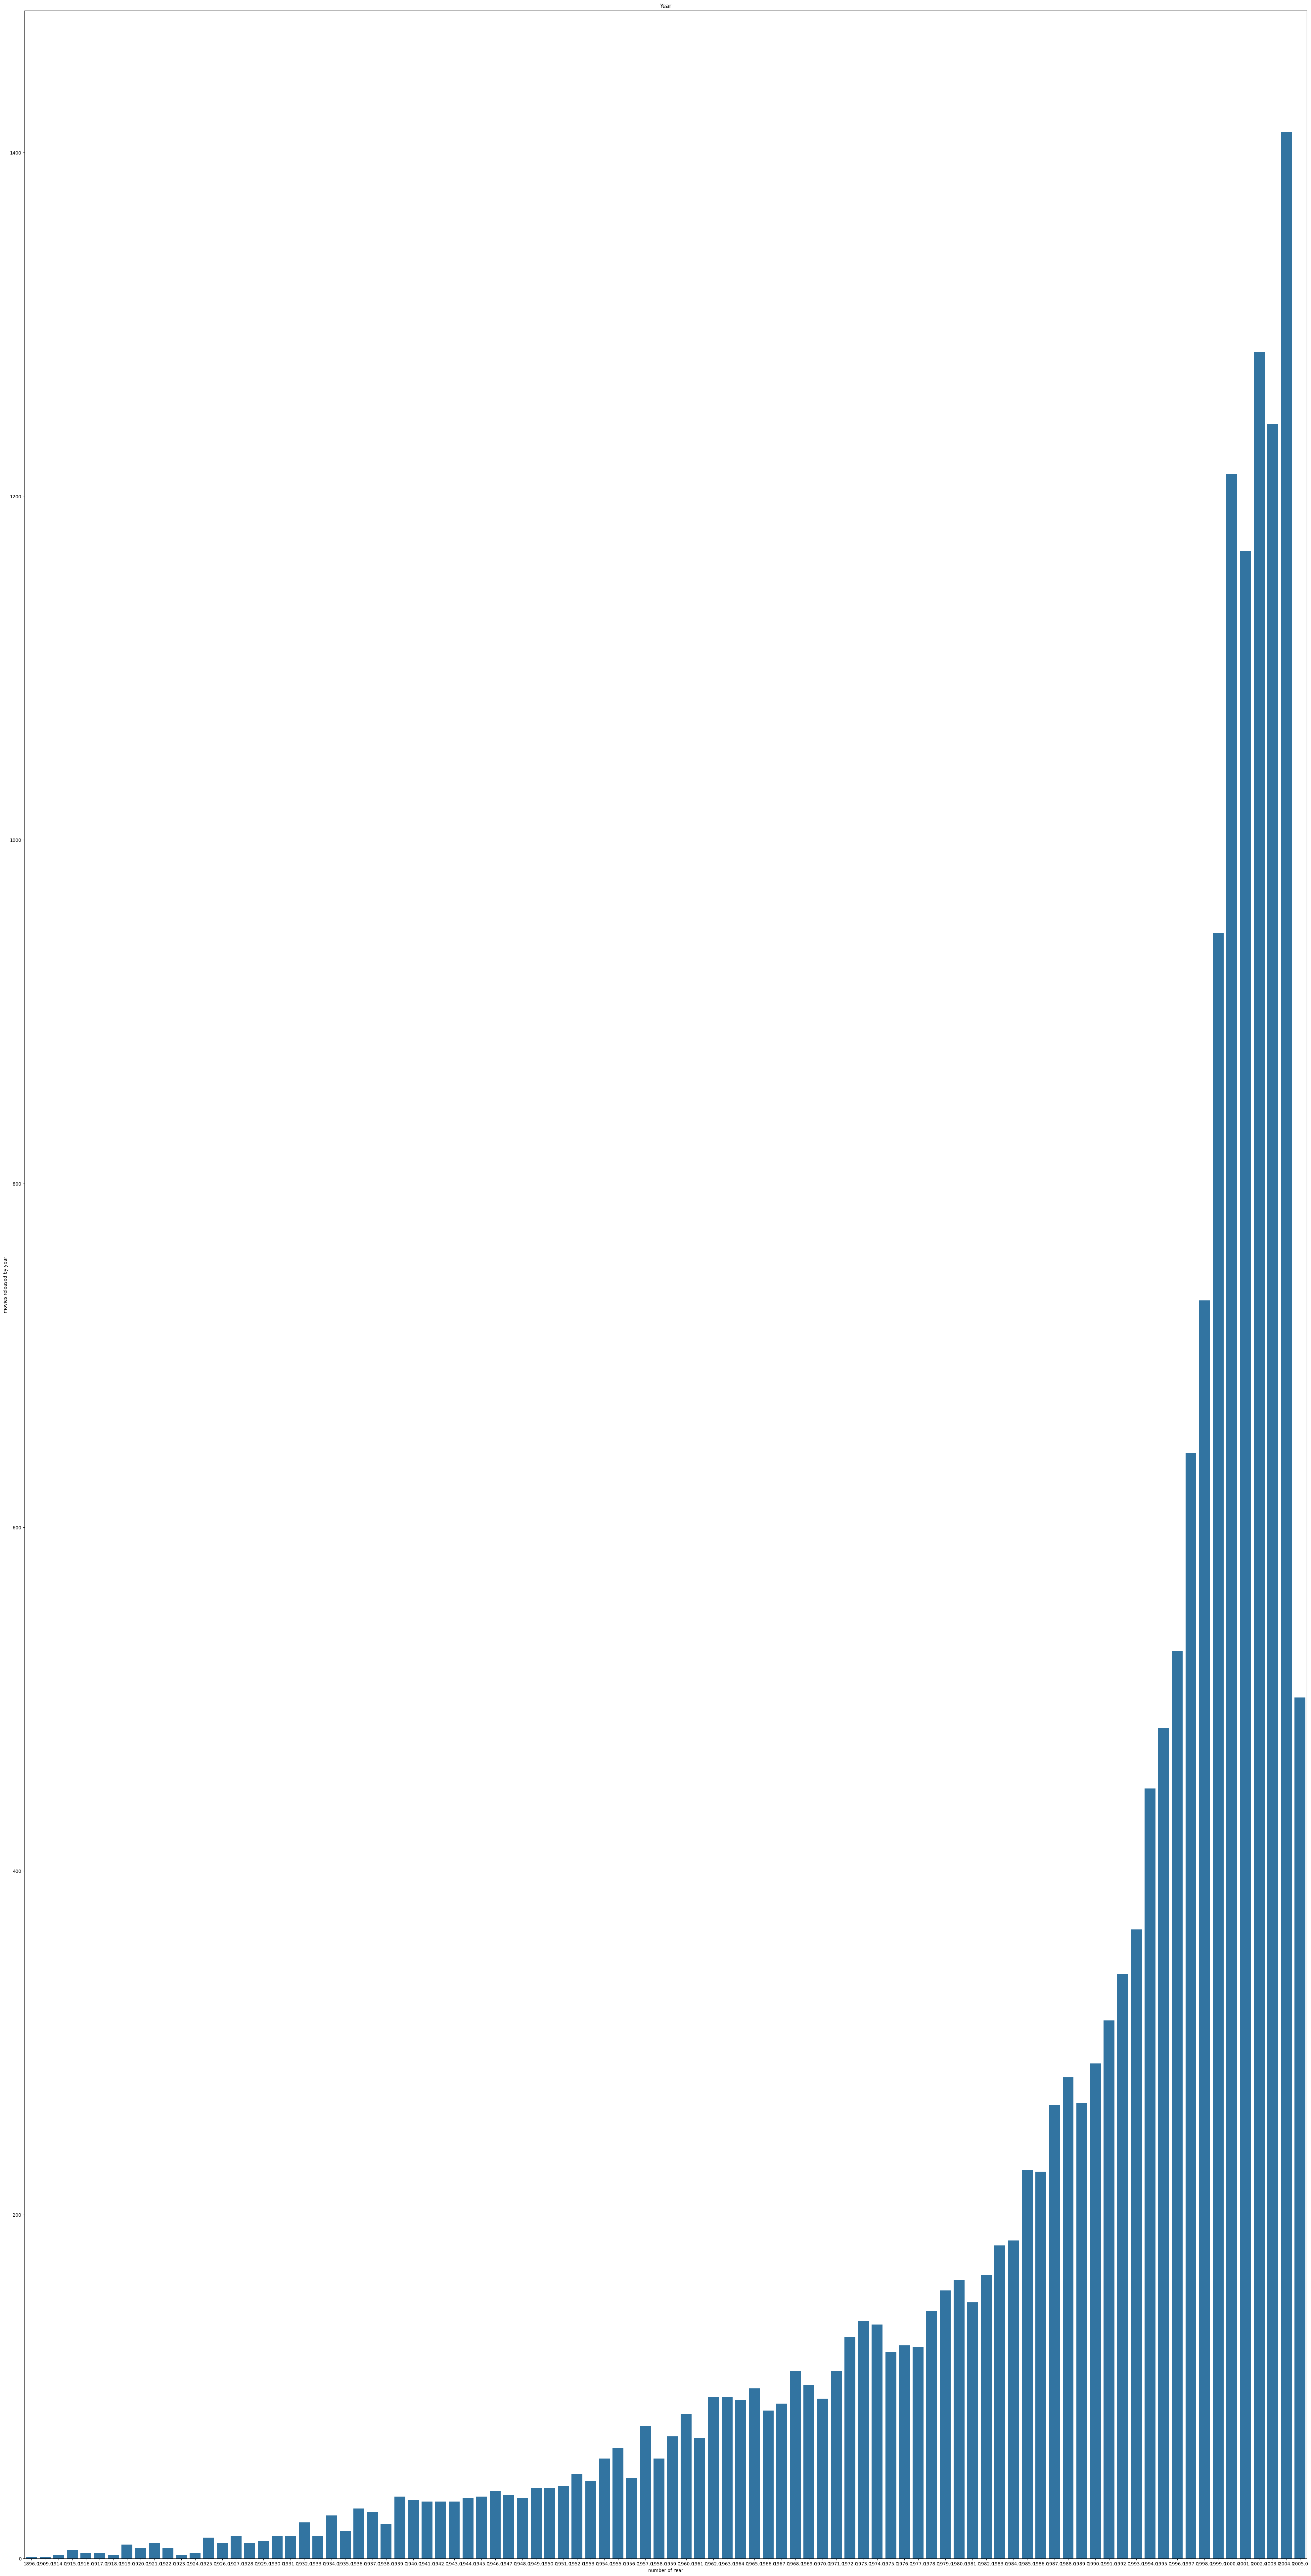

In [ ]:
movies_by_yer = df['year'].value_counts().sort_index()

plt.figure(figsize=(50,100))
sns.barplot(x=movies_by_yer.index, y=movies_by_yer.values)
plt.title('Year')
plt.xlabel('number of Year')
plt.ylabel('movies released by year')
plt.show()

## Top 20 Years with Most Movies

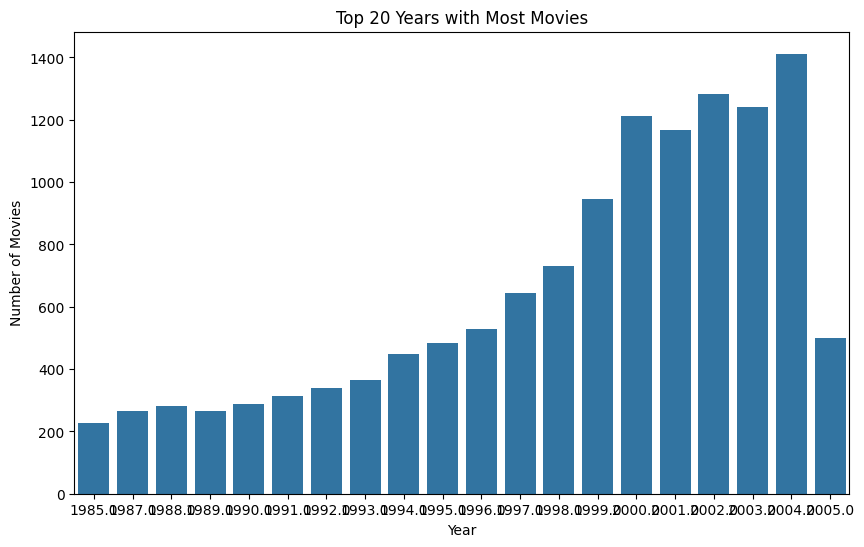

In [ ]:
top_years = df['year'].value_counts().head(20)
plt.figure(figsize=(10,6))
sns.barplot(x=top_years.index, y=top_years.values)
plt.title('Top 20 Years with Most Movies')
plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.show()

## Distribution of Movies Release Years

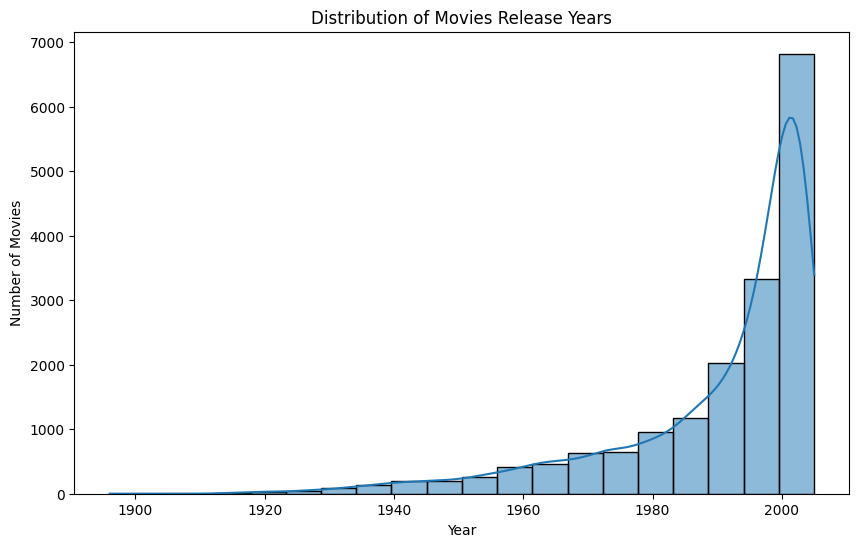

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(df['year'], bins=20, kde=True)
plt.title('Distribution of Movies Release Years')
plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.show()

## Movies Released After 2000

In [ ]:
df[df['year'] > 2000].head(20)

,movie_id,year,name
0,2,2004.0,Isle of Man TT 2004 Review
3,5,2004.0,The Rise and Fall of ECW
6,8,2004.0,What the #$*! Do We Know!?
8,10,2001.0,Fighter
11,13,2003.0,Lord of the Rings: The Return of the King: Ext...
15,17,2005.0,7 Seconds
19,21,2002.0,Strange Relations
21,23,2001.0,Clifford: Clifford Saves the Day! / Clifford's...
24,26,2004.0,Never Die Alone
26,28,2002.0,Lilo and Stitch


## Feature Engineering

In [ ]:
df['Name_Length'] = df['name'].apply(len)
df.head()

,movie_id,year,name,Name_Length
0,2,2004.0,Isle of Man TT 2004 Review,26
1,3,1997.0,Character,9
2,4,1994.0,Paula Abdul's Get Up & Dance,28
3,5,2004.0,The Rise and Fall of ECW,24
4,6,1997.0,Sick,4


In [ ]:
df['Word_Count'] = df['name'].apply(lambda x: len(str(x).split()))
df.head()

,movie_id,year,name,Name_Length,Word_Count
0,2,2004.0,Isle of Man TT 2004 Review,26,6
1,3,1997.0,Character,9,1
2,4,1994.0,Paula Abdul's Get Up & Dance,28,6
3,5,2004.0,The Rise and Fall of ECW,24,6
4,6,1997.0,Sick,4,1


In [ ]:
df['Name_Length'].describe()

,Name_Length
count,17426.000000
mean,20.913979
std,12.462632
min,1.000000
25%,12.000000
50%,18.000000
75%,27.000000
max,108.000000


In [ ]:
df.nlargest(10, 'Name_Length')[['name', 'Name_Length']]

,name,Name_Length
6941,The Peter Rabbit Collection: The Tale of the F...,108
15297,Classic Sci-Fi Movies: In the Year 2889 / They...,98
10389,The Great Ecstasy of the Sculptor Steiner / Ho...,97
4417,The Peter Rabbit Collection: The Tale of Peter...,94
1355,Jet Li and the Legend of Wong Fei Hung: Unconq...,93
7367,Masters of Poker: Annie Duke's Advanced Texas ...,88
6089,Masters of Poker: Vol. 2: Phil Hellmuth's Mill...,86
1167,Masters of Poker: Phil Hellmuth's Million Doll...,84
4347,Disney's Learning Adventures: Mickey's Around ...,84
2506,Astronomy Adventure: Learning Astronomy Histor...,83


In [ ]:
df.nsmallest(10, 'Name_Length')[['name', 'Name_Length']]

,name,Name_Length
5940,X,1
5974,M,1
6289,H,1
8577,O,1
9837,Z,1
1206,It,2
2890,10,2
4941,54,2
7625,Go,2
9659,CQ,2


## Text Cleaning

In [ ]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\W', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df['clean_name'] = df['name'].apply(clean_text)

df[['name','clean_name']].head(10)

,name,clean_name
0,Isle of Man TT 2004 Review,isle of man tt 2004 review
1,Character,character
2,Paula Abdul's Get Up & Dance,paula abdul s get up dance
3,The Rise and Fall of ECW,the rise and fall of ecw
4,Sick,sick
5,8 Man,8 man
6,What the #$*! Do We Know!?,what the do we know
7,Class of Nuke 'Em High 2,class of nuke em high 2
8,Fighter,fighter
9,Full Frame: Documentary Shorts,full frame documentary shorts


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
tfidf = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1,2)
)

tfidf_matrix = tfidf.fit_transform(df['clean_name'])

tfidf_matrix.shape

(17426, 32137)

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(tfidf_matrix)

In [ ]:
def recommend_movies(movie_name, num_recommendations=10):

    movie_name = movie_name.lower()

    if movie_name not in indices:
        return "Movie not found in dataset."

    idx = indices[movie_name]

    similarity_scores = list(enumerate(cosine_sim[idx]))

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    similarity_scores = similarity_scores[1:num_recommendations+1]

    movie_indices = [i[0] for i in similarity_scores]

    # Fixed column names to match the lowercase names in the DataFrame
    recommendations = df.iloc[movie_indices][
        ['movie_id', 'name', 'year']
    ]

    return recommendations

In [ ]:
df.reset_index(drop=True, inplace=True)
indices = pd.Series(df.index, index=df['clean_name']).drop_duplicates()
recommend_movies('Dinosaur Planet')

'Movie not found in dataset.'

In [ ]:
recommend_movies('The Company')

,movie_id,name,year
17424,17769,The Company,2003.0
6407,6529,Three's Company: Season 1,1977.0
9168,9337,Three's Company: Season 4,1979.0
13957,14225,Three's Company: Season 3,1978.0
15418,15716,Three's Company: Season 2,1977.0
3325,3388,Company Man,2000.0
2037,2073,Two's Company: Series 1,1975.0
3579,3651,Bad Company,1972.0
5442,5545,Bad Company,2002.0
9341,9516,Bad Company,1995.0


In [ ]:
recommend_movies('Alien Hunter')

,movie_id,name,year
10645,10844,The Hunter,1980.0
15310,15606,Alien from L.A.,1988.0
1580,1609,Hunter: Season 1,1984.0
3403,3469,The Night of the Hunter,1955.0
12953,13200,Night Hunter,1995.0
8858,9025,City Hunter,1993.0
17285,17628,Vampire Hunter D,1985.0
15546,15847,Hunter's Moon,1999.0
2703,2752,Alien Planet,2005.0
16731,17063,The Crocodile Hunter,2000.0


In [ ]:
def search_movie(keyword, n=10):

    result = df[
        df['name'].str.contains(
            keyword,
            case=False,
            na=False
        )
    ]

    return result[['movie_id', 'name', 'year']].head(n)

In [ ]:
search_movie('Star')

,movie_id,name,year
135,138,Star Trek: Voyager: Season 1,1995.0
206,209,Star Trek: Deep Space Nine: Season 5,1996.0
232,235,Unhook the Stars,1996.0
333,337,Star 80,1983.0
341,345,Star Trek: Voyager: Season 5,1998.0
358,363,Stark Raving Mad,2002.0
455,462,Classic Cartoon Favorites: Starring Donald,2005.0
535,543,Roughnecks: The Starship Troopers Chronicles: ...,1999.0
552,560,Star Trek: Enterprise: Season 3,2003.0
619,629,Firestarter,1984.0


In [ ]:
search_movie('Harry')

,movie_id,name,year
526,534,With a Friend Like Harry,2000.0
1493,1521,The Trouble With Harry,1955.0
2371,2412,Harry Potter and the Prisoner of Azkaban: Bonu...,2004.0
2613,2660,When Harry Met Sally,1989.0
5085,5182,Harry and Max,2004.0
5366,5466,Harry Connick Jr.: The New York Big Band Concert,1993.0
6986,7114,Discovering the Real World of Harry Potter,2002.0
6994,7123,Harry and Walter Go to New York,1976.0
7337,7469,The Harryhausen Chronicles,1998.0
7866,8003,Harry Connick Jr.: Only You,2004.0


In [ ]:
movie = input("Enter a movie name: ")

print("\nRecommended Movies:\n")

recommend_movies(movie, 10)

Enter a movie name: 10

Recommended Movies:



,movie_id,name,year
6533,6656,10.5,2004.0
11750,11972,10 to Midnight,1983.0
6618,6742,3:10 to Yuma,1957.0
17312,17655,10 Attitudes,2001.0
10123,10311,The Twilight Zone: Vol. 10,1961.0
6772,6898,Dark Shadows: Vol. 10,1968.0
8829,8996,10 Tokyo Warriors,2004.0
3397,3463,10 Things I Hate About You,1999.0
6518,6641,Force 10 from Navarone,1978.0
14262,14538,How to Lose a Guy in 10 Days,2003.0


# Netflix Movie Dataset
        ↓
# Data Collection
        ↓
# Data Cleaning
        ↓
# Missing Value Handling
        ↓
# Duplicate Removal
        ↓
# Exploratory Data Analysis
        ↓
## Feature Engineering
        ↓
## Text Cleaning
        ↓
## TF-IDF Vectorization
        ↓
## Cosine Similarity
##        ↓
## Recommendation Engine
        ↓
## Top 10 Similar Movies